In [1]:
%cd ..

/data/current/projects/tcrio/tcrio


In [2]:
from tcr_io.filters import Filterer 
from tcr_io.ingestion import DatasetIngester
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from tcr_io.mappers import RegexMapper
from pathlib import Path
import polars as pl

In [4]:


from tcr_io.dataset import TcrDataset

In [5]:
ds = TcrDataset(
    "/data/current/tcrio_db/breens_2026"
)

In [6]:
from tcr_io.operations import MaitHits

In [7]:
ds.run_operation(MaitHits())

Counting mait hits in repertoires:   0%|          | 0/30 [00:00<?, ?it/s]

Counting mait hits in repertoires: 100%|██████████| 30/30 [00:00<00:00, 173.91it/s]

Writing DataFrame to /data/current/tcrio_db/breens_2026/meta/repertoire/mait_hits.parquet


In [8]:
res = ds.get_operation_result("mait_hits")

In [10]:
res

repertoire_id,n_mait_hits,total_mait_duplicates,median_mait_duplicates,mean_mait_duplicates,mait_breadth,mait_breadth_err,mait_depth,mait_depth_err,mait_evenness
str,u32,i64,f64,f64,f64,f64,f64,f64,f64
"""CO092+CD8""",11,382,5.0,34.727273,0.00227,0.000685,17.804908,1.714939,0.257047
"""PT147+CD4""",12,247,8.0,20.583333,0.000746,0.000215,22.668163,1.686175,0.493859
"""PT080+CD4""",11,221,7.0,20.090909,0.000536,0.000162,18.616677,1.632333,0.505499
"""PT105+CD8""",5,154,14.0,30.8,0.001086,0.000486,1.561059,0.945532,0.535195
"""PT066+CD8""",7,180,9.0,25.714286,0.001448,0.000548,6.85508,1.276285,0.522909
…,…,…,…,…,…,…,…,…,…
"""PT118+CD8""",23,4363,5.0,189.695652,0.005164,0.00108,61.044447,2.555686,0.111788
"""PT131+CD4""",9,187,4.0,20.777778,0.00106,0.000353,8.413123,1.716375,0.346109
"""PT086+CD8""",22,308,8.0,14.0,0.004403,0.000941,50.777857,2.39843,0.560569


<Axes: xlabel='mait_breadth', ylabel='total_mait_duplicates'>

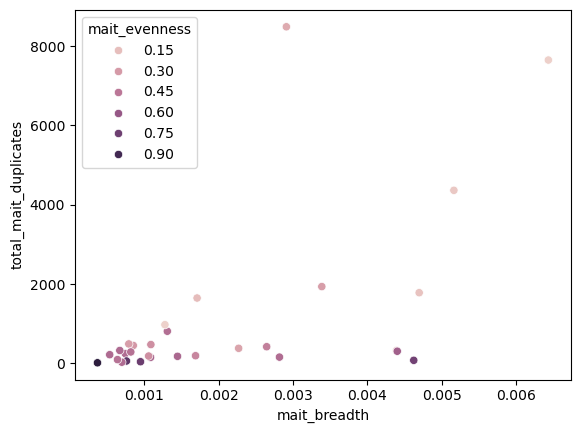

In [11]:
sns.scatterplot(
    data=res,
    x="mait_breadth",
    y="total_mait_duplicates",
    hue="mait_evenness",
)

<Axes: xlabel='mait_breadth', ylabel='mait_depth'>

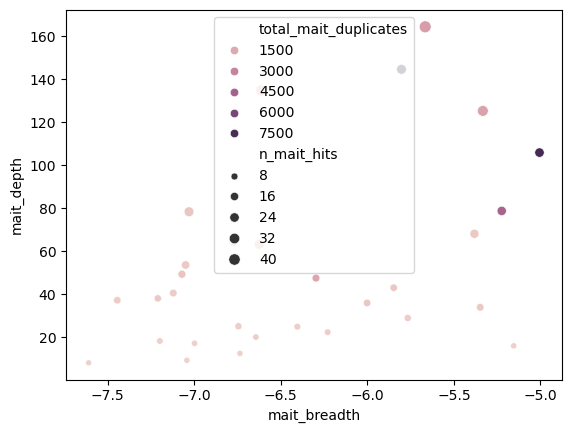

In [14]:
sns.scatterplot(
    data=res,
    x="mait_breadth",
    y="mait_depth",
    hue="total_mait_duplicates",
    size="n_mait_hits",
)

In [17]:
ds.operations_meta["description"].to_list()

['Generates a report summarizing the reasons for filtering failures across repertoires.',
 'Infers HLA types from TCR repertoires using the method from HLA2TCR.',
 'Infers HLA types from TCR repertoires using the method from HLA2TCR. Does not group by patient',
 'Analyzes the overlap between repertoires, calculating the number of shared clonotypes and the Spearman correlation between their frequencies.',
 'Fetches study metadata (title, abstract, authors, year, etc.) based on provided identifiers',
 'Generates a report summarizing diversity metrics across repertoires.',
 'Generates a report summarizing diversity metrics across repertoires.',
 'Generates a report summarizing diversity metrics across repertoires.',
 'Generates a report summarizing inferred likely VDJ trimming and insertion metrics across repertoires.',
 'Counts the V and J gene usage frequencies, and computes the surprise of their combinations.',
 'Counts the number of CMV ecocluster hits for each repertoire.',
 'Counts 

In [18]:
from tcr_io.operations.hla import get_hla_class_counts

h_counts = get_hla_class_counts(ds)

/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [19]:
h_counts

repertoire_id,A,B,C,DP,DQ,DR,class_i_to_ii_ratio,class_i,class_ii,A_wt,B_wt,C_wt,DP_wt,DQ_wt,DR_wt,class_i_to_ii_ratio_wt,class_i_wt,class_ii_wt,A_wt_with_max,B_wt_with_max,C_wt_with_max,DP_wt_with_max,DQ_wt_with_max,DR_wt_with_max,class_i_to_ii_ratio_wt_with_max,class_i_wt_with_max,class_ii_wt_with_max
str,u32,u32,u32,u32,u32,u32,f64,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""67a3d20b5c92809cf36a9ad6""",208,364,177,281,1561,1547,-1.508512,749,3389,68.13874,48.470224,5.502431,19.791919,203.984355,39.541062,-0.764061,122.111395,263.317336,270717.120821,147390.597028,26991.558632,106190.981357,3.9003e6,576132.811244,-2.331735,445099.276481,4.5827e6
"""67a3d24b5c92809cf36a9b82""",268,515,253,473,2710,2744,-1.743355,1036,5927,72.936597,46.56267,47.643491,175.573461,985.552453,1179.791725,-2.633912,167.142759,2340.917639,223201.108713,135186.065238,178535.438445,836317.142612,3.3455e7,3.5820e7,-4.871984,536922.612396,7.0111e7
"""67a2aa4506b40cb07c7a6b31""",195,412,181,227,1222,1278,-1.240558,788,2727,40.8737,89.16865,33.305298,48.976997,30.911323,177.306092,-0.451729,163.347648,257.194412,141916.762226,374039.890241,123059.800439,248973.613626,470027.050033,5.4886e6,-2.273604,639016.452906,6.2076e6
"""67a2aa4706b40cb07c7a6b38""",376,622,322,456,1958,1992,-1.204805,1320,4406,192.850244,141.92824,89.124198,128.729712,110.780218,171.378277,0.031108,423.902682,410.888207,873010.544627,1.4551e6,525420.462636,972939.501353,1.9466e6,5.5858e6,-1.09213,2.8536e6,8.5054e6
"""67a2aa4906b40cb07c7a6b3d""",345,663,366,461,2299,2282,-1.299547,1374,5042,109.581131,64.959652,89.843062,57.798147,92.015583,128.779606,-0.052159,264.383845,278.593336,507097.02559,656471.093417,551528.787924,278408.667389,1.4527e6,3.5465e6,-1.123991,1.7151e6,5.2775e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""67a3d2505c92809cf36a9b90""",339,533,285,399,2117,1994,-1.359824,1157,4510,180.170735,170.055905,141.099527,100.892782,599.350934,467.217406,-0.864301,491.326167,1167.461123,667154.824923,1.5734e6,682817.229621,809477.863286,1.0460e7,1.0580e7,-2.011444,2.9233e6,2.1849e7
"""67a2aa8106b40cb07c7a6bd7""",198,440,210,290,1544,1439,-1.349709,848,3273,1.698476,2.55853,3.989587,27.833706,25.103224,6.644151,-1.879728,8.246593,59.581081,6525.383816,13237.278535,14098.314592,234189.067554,912788.909418,177571.214228,-3.666535,33860.976944,1.3245e6
"""67a2aa8106b40cb07c7a6bd8""",246,567,249,354,1436,1331,-1.077379,1062,3121,44.367179,55.285818,8.39704,109.031917,14.660723,15.691173,-0.252573,108.050036,139.383813,128029.586965,242880.639382,21717.363673,890615.236485,416360.701823,550591.447337,-1.554159,392627.59002,1.8576e6


In [20]:
gene_counts_summary = ds.get_operation_result("gene_counts_summary")

In [21]:
pl.Config.set_tbl_cols(10000)

polars.config.Config

In [22]:
gene_counts_summary

repertoire_id,TRBV2,TRBV3-1,TRBV4-1,TRBV4-2,TRBV4-3,TRBV5-1,TRBV5-4,TRBV5-5,TRBV5-6,TRBV5-8,TRBV6-1,TRBV6-3,TRBV6-4,TRBV6-5,TRBV6-6,TRBV6-8,TRBV6-9,TRBV7-2,TRBV7-3,TRBV7-4,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-3,TRBV12-4,TRBV12-5,TRBV13,TRBV14,TRBV15,TRBV16,TRBV18,TRBV19,TRBV20-1,TRBV24-1,TRBV25-1,TRBV27,TRBV28,TRBV29-1,TRBV30,TRBJ1-1,TRBJ1-2,TRBJ1-3,TRBJ1-4,TRBJ1-5,TRBJ1-6,TRBJ2-1,TRBJ2-2,TRBJ2-3,TRBJ2-4,TRBJ2-5,TRBJ2-6,TRBJ2-7,bias_TRBV2+TRBJ1-1,bias_TRBV2+TRBJ1-2,bias_TRBV2+TRBJ1-3,bias_TRBV2+TRBJ1-4,bias_TRBV2+TRBJ1-5,bias_TRBV2+TRBJ1-6,bias_TRBV2+TRBJ2-1,bias_TRBV2+TRBJ2-2,bias_TRBV2+TRBJ2-3,bias_TRBV2+TRBJ2-4,bias_TRBV2+TRBJ2-5,bias_TRBV2+TRBJ2-6,bias_TRBV2+TRBJ2-7,bias_TRBV3-1+TRBJ1-1,bias_TRBV3-1+TRBJ1-2,bias_TRBV3-1+TRBJ1-3,bias_TRBV3-1+TRBJ1-4,bias_TRBV3-1+TRBJ1-5,bias_TRBV3-1+TRBJ1-6,bias_TRBV3-1+TRBJ2-1,bias_TRBV3-1+TRBJ2-2,bias_TRBV3-1+TRBJ2-3,bias_TRBV3-1+TRBJ2-4,bias_TRBV3-1+TRBJ2-5,bias_TRBV3-1+TRBJ2-6,bias_TRBV3-1+TRBJ2-7,bias_TRBV4-1+TRBJ1-1,bias_TRBV4-1+TRBJ1-2,bias_TRBV4-1+TRBJ1-3,bias_TRBV4-1+TRBJ1-4,bias_TRBV4-1+TRBJ1-5,bias_TRBV4-1+TRBJ1-6,bias_TRBV4-1+TRBJ2-1,bias_TRBV4-1+TRBJ2-2,bias_TRBV4-1+TRBJ2-3,bias_TRBV4-1+TRBJ2-4,bias_TRBV4-1+TRBJ2-5,bias_TRBV4-1+TRBJ2-6,bias_TRBV4-1+TRBJ2-7,bias_TRBV4-2+TRBJ1-1,bias_TRBV4-2+TRBJ1-2,bias_TRBV4-2+TRBJ1-3,bias_TRBV4-2+TRBJ1-4,bias_TRBV4-2+TRBJ1-5,bias_TRBV4-2+TRBJ1-6,bias_TRBV4-2+TRBJ2-1,bias_TRBV4-2+TRBJ2-2,bias_TRBV4-2+TRBJ2-3,bias_TRBV4-2+TRBJ2-4,bias_TRBV4-2+TRBJ2-5,bias_TRBV4-2+TRBJ2-6,bias_TRBV4-2+TRBJ2-7,bias_TRBV4-3+TRBJ1-1,bias_TRBV4-3+TRBJ1-2,bias_TRBV4-3+TRBJ1-3,bias_TRBV4-3+TRBJ1-4,bias_TRBV4-3+TRBJ1-5,bias_TRBV4-3+TRBJ1-6,bias_TRBV4-3+TRBJ2-1,bias_TRBV4-3+TRBJ2-2,bias_TRBV4-3+TRBJ2-3,bias_TRBV4-3+TRBJ2-4,bias_TRBV4-3+TRBJ2-5,bias_TRBV4-3+TRBJ2-6,bias_TRBV4-3+TRBJ2-7,bias_TRBV5-1+TRBJ1-1,bias_TRBV5-1+TRBJ1-2,bias_TRBV5-1+TRBJ1-3,bias_TRBV5-1+TRBJ1-4,bias_TRBV5-1+TRBJ1-5,bias_TRBV5-1+TRBJ1-6,bias_TRBV5-1+TRBJ2-1,bias_TRBV5-1+TRBJ2-2,bias_TRBV5-1+TRBJ2-3,bias_TRBV5-1+TRBJ2-4,bias_TRBV5-1+TRBJ2-5,bias_TRBV5-1+TRBJ2-6,bias_TRBV5-1+TRBJ2-7,bias_TRBV5-4+TRBJ1-1,bias_TRBV5-4+TRBJ1-2,bias_TRBV5-4+TRBJ1-3,bias_TRBV5-4+TRBJ1-4,bias_TRBV5-4+TRBJ1-5,bias_TRBV5-4+TRBJ1-6,bias_TRBV5-4+TRBJ2-1,bias_TRBV5-4+TRBJ2-2,bias_TRBV5-4+TRBJ2-3,bias_TRBV5-4+TRBJ2-4,bias_TRBV5-4+TRBJ2-5,bias_TRBV5-4+TRBJ2-6,bias_TRBV5-4+TRBJ2-7,bias_TRBV5-5+TRBJ1-1,bias_TRBV5-5+TRBJ1-2,bias_TRBV5-5+TRBJ1-3,bias_TRBV5-5+TRBJ1-4,bias_TRBV5-5+TRBJ1-5,bias_TRBV5-5+TRBJ1-6,bias_TRBV5-5+TRBJ2-1,bias_TRBV5-5+TRBJ2-2,bias_TRBV5-5+TRBJ2-3,bias_TRBV5-5+TRBJ2-4,bias_TRBV5-5+TRBJ2-5,bias_TRBV5-5+TRBJ2-6,bias_TRBV5-5+TRBJ2-7,bias_TRBV5-6+TRBJ1-1,bias_TRBV5-6+TRBJ1-2,bias_TRBV5-6+TRBJ1-3,bias_TRBV5-6+TRBJ1-4,bias_TRBV5-6+TRBJ1-5,bias_TRBV5-6+TRBJ1-6,bias_TRBV5-6+TRBJ2-1,bias_TRBV5-6+TRBJ2-2,bias_TRBV5-6+TRBJ2-3,bias_TRBV5-6+TRBJ2-4,bias_TRBV5-6+TRBJ2-5,bias_TRBV5-6+TRBJ2-6,bias_TRBV5-6+TRBJ2-7,bias_TRBV5-8+TRBJ1-1,bias_TRBV5-8+TRBJ1-2,bias_TRBV5-8+TRBJ1-3,bias_TRBV5-8+TRBJ1-4,bias_TRBV5-8+TRBJ1-5,bias_TRBV5-8+TRBJ1-6,bias_TRBV5-8+TRBJ2-1,bias_TRBV5-8+TRBJ2-2,bias_TRBV5-8+TRBJ2-3,bias_TRBV5-8+TRBJ2-4,bias_TRBV5-8+TRBJ2-5,bias_TRBV5-8+TRBJ2-6,bias_TRBV5-8+TRBJ2-7,bias_TRBV6-1+TRBJ1-1,bias_TRBV6-1+TRBJ1-2,bias_TRBV6-1+TRBJ1-3,bias_TRBV6-1+TRBJ1-4,bias_TRBV6-1+TRBJ1-5,bias_TRBV6-1+TRBJ1-6,bias_TRBV6-1+TRBJ2-1,bias_TRBV6-1+TRBJ2-2,bias_TRBV6-1+TRBJ2-3,bias_TRBV6-1+TRBJ2-4,bias_TRBV6-1+TRBJ2-5,bias_TRBV6-1+TRBJ2-6,bias_TRBV6-1+TRBJ2-7,bias_TRBV6-3+TRBJ1-1,bias_TRBV6-3+TRBJ1-2,bias_TRBV6-3+TRBJ1-3,bias_TRBV6-3+TRBJ1-4,bias_TRBV6-3+TRBJ1-5,bias_TRBV6-3+TRBJ1-6,bias_TRBV6-3+TRBJ2-1,bias_TRBV6-3+TRBJ2-2,bias_TRBV6-3+TRBJ2-3,bias_TRBV6-3+TRBJ2-4,bias_TRBV6-3+TRBJ2-5,bias_TRBV6-3+TRBJ2-6,bias_TRBV6-3+TRBJ2-7,bias_TRBV6-4+TRBJ1-1,bias_TRBV6-4+TRBJ1-2,bias_TRBV6-4+TRBJ1-3,bias_TRBV6-4+TRBJ1-4,bias_TRBV6-4+TRBJ1-5,bias_TRBV6-4+TRBJ1-6,bias_TRBV6-4+TRBJ2-1,bias_TRBV6-4+TRBJ2-2,bias_TRBV6-4+TRBJ2-3,bias_TRBV6-4+TRBJ2-4,bias_TRBV6-4+TRBJ2-5,bias_TRBV6-4+TRBJ2-6,bias_TRBV6-4+

In [23]:
gene_counts_summary = gene_counts_summary.with_columns(
    abs_total_surprise = pl.sum_horizontal(pl.selectors.starts_with("bias_").abs()),
    total_pos_surprise = pl.sum_horizontal(pl.selectors.starts_with("bias_").clip(lower_bound=0)),
    total_neg_surprise = -pl.sum_horizontal(pl.selectors.starts_with("bias_").clip(upper_bound=0)),
)

In [25]:
ds.operations

[OperationMeta(operation_name='filtering_report', version='0.2', ran_at='2026-06-07 14:33:11.334177', duration_s=83.32285332679749, status='success', error=None, description='Generates a report summarizing the reasons for filtering failures across repertoires.', outputs=['qc/filter/filter_summary.parquet', 'qc/filter/filter_top_invalid_junction_aa.parquet', 'qc/filter/filter_top_invalid_v_call.parquet', 'qc/filter/filter_top_non_functional_v_call.parquet', 'qc/filter/filter_top_invalid_j_call.parquet', 'qc/filter/filter_top_non_functional_j_call.parquet']),
 OperationMeta(operation_name='hla_inference', version='0.4', ran_at='2026-06-07 14:34:08.296794', duration_s=56.92306303977966, status='success', error=None, description='Infers HLA types from TCR repertoires using the method from HLA2TCR.', outputs=['meta/patient/inferred_hla.parquet', 'meta/patient/inferred_hla_long.parquet']),
 OperationMeta(operation_name='repertoire_hla_inference', version='0.2', ran_at='2026-06-07 14:35:06.97

In [100]:
stat = ds.full_repertoire_meta.join(
    ds.get_operation_result("vdj_statistics_summary"),
    on="repertoire_id",
).join(
    ds.get_operation_result("diversity_report"),
    on="repertoire_id",
    how="left"
).join(
    ds.get_operation_result("ecocluster_hits"),
    on="repertoire_id",
    how="left"
).join(
    h_counts,
    on="repertoire_id",
    how="left"
).join(
    gene_counts_summary,
    on="repertoire_id",
    how="left",
).with_columns(
    class_ii_log_diff = pl.col("class_ii").log(2) - pl.col("n_clonotypes").log(2),
    class_i_log_diff = pl.col("class_i").log(2) - pl.col("n_clonotypes").log(2),
).join(
    ds.get_operation_result("mait_hits"),
    on="repertoire_id",
    how="left"
)

In [88]:
import joblib

def get_X_y(ds):
    ds.run_operation(GeneCountsSummary())

    reps = ds.repertoire_meta.select(["repertoire_id", "n_clonotypes"])
    X = ds.get_operation_result("gene_counts_summary")
    X = reps.join(X, on="repertoire_id", how="inner")
    X = X.drop("repertoire_id").fill_null(0).to_numpy()

    y = get_hla_class_counts(ds).select(["repertoire_id", "class_i_to_ii_ratio"])
    y = reps.select(["repertoire_id"]).join(y, on="repertoire_id", how="left")["class_i_to_ii_ratio"].to_numpy()

    return X,y

ratio_model = joblib.load("/data/current/projects/tcrio_db_exploration/hla_class_i_to_ii_ratio_predictor.joblib")

In [87]:
ratio_model

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.3, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [89]:
ratio_X = get_X_y(ds)[0]

In [91]:
ratio_y = ratio_model.predict(ratio_X)

In [101]:
stat = stat.with_columns(
    modeled_cd4_cd8_ratio = pl.Series(ratio_y)
)

In [102]:
stat_annot = stat.join(
    ds.full_patient_meta.select(["patient_id", "age", "sex"]),
    on="patient_id",
    how="left"
).with_columns(
        frac_mait_hits = pl.col("n_mait_hits") / pl.col("n_clonotypes")
)

In [103]:
X_df = stat.drop(["source_files", "repertoire_id", "patient_id"]).drop(pl.selectors.ends_with("_kurtosis"))
X = X_df.to_numpy()
feature_names = X_df.columns
y = stat_annot["age"].to_numpy()


In [104]:
import seaborn as sns

<Axes: xlabel='n_clonotypes', ylabel='n_hits'>

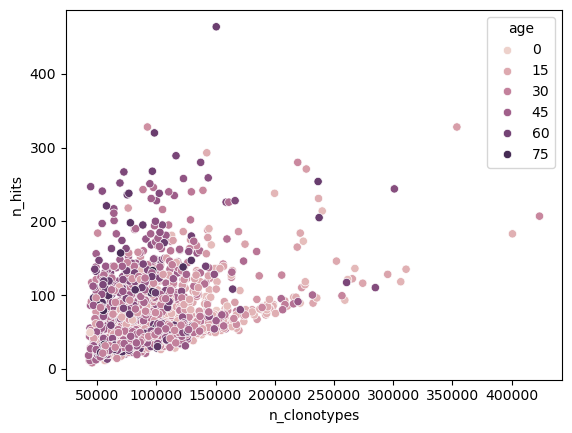

In [105]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)).with_columns(
    ),
    x="n_clonotypes",
    y="n_hits",
    hue="age",
)

<Axes: xlabel='class_i_to_ii_ratio', ylabel='n_hits'>

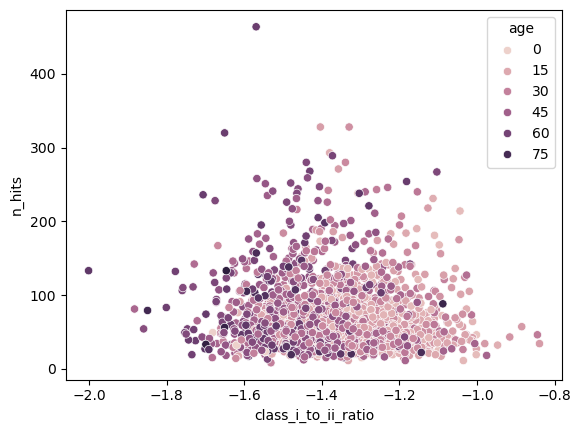

In [106]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)).with_columns(
    ),
    x="class_i_to_ii_ratio",
    y="n_hits",
    hue="age",
)

<Axes: xlabel='class_i_to_ii_ratio', ylabel='modeled_cd4_cd8_ratio'>

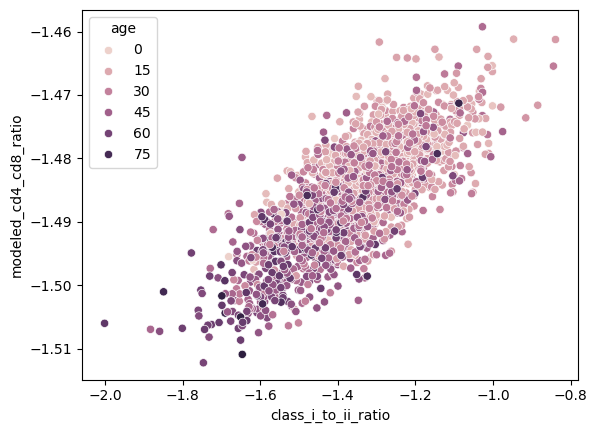

In [107]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)).with_columns(
    ),
    x="class_i_to_ii_ratio",
    y="modeled_cd4_cd8_ratio",
    hue="age",
)

In [108]:
stat_annot

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,n_v_trim_mean,n_v_trim_std,n_v_trim_skew,n_v_trim_kurtosis,n_v_trim_q10,n_v_trim_q25,n_v_trim_q50,n_v_trim_q75,n_v_trim_q90,n_v_trim_sum,n_vd_trim_mean,n_vd_trim_std,n_vd_trim_skew,n_vd_trim_kurtosis,n_vd_trim_q10,n_vd_trim_q25,n_vd_trim_q50,n_vd_trim_q75,n_vd_trim_q90,n_vd_trim_sum,n_vj_trim_mean,n_vj_trim_std,n_vj_trim_skew,n_vj_trim_kurtosis,n_vj_trim_q10,n_vj_trim_q25,n_vj_trim_q50,n_vj_trim_q75,n_vj_trim_q90,n_vj_trim_sum,n_j_trim_mean,n_j_trim_std,n_j_trim_skew,n_j_trim_kurtosis,n_j_trim_q10,n_j_trim_q25,n_j_trim_q50,n_j_trim_q75,n_j_trim_q90,n_j_trim_sum,n_vd_ins_mean,n_vd_ins_std,n_vd_ins_skew,n_vd_ins_kurtosis,n_vd_ins_q10,n_vd_ins_q25,n_vd_ins_q50,n_vd_ins_q75,n_vd_ins_q90,n_vd_ins_sum,n_dj_ins_mean,n_dj_ins_std,n_dj_ins_skew,n_dj_ins_kurtosis,n_dj_ins_q10,n_dj_ins_q25,n_dj_ins_q50,n_dj_ins_q75,n_dj_ins_q90,n_dj_ins_sum,n_trims_mean,n_trims_std,n_trims_skew,n_trims_kurtosis,n_trims_q10,n_trims_q25,n_trims_q50,n_trims_q75,n_trims_q90,n_trims_sum,n_ins_mean,n_ins_std,n_ins_skew,n_ins_kurtosis,n_ins_q10,n_ins_q25,n_ins_q50,n_ins_q75,n_ins_q90,n_ins_sum,cdr3_end_mean,cdr3_end_std,cdr3_end_skew,cdr3_end_kurtosis,cdr3_end_q10,cdr3_end_q25,cdr3_end_q50,cdr3_end_q75,cdr3_end_q90,cdr3_end_sum,frac_untemplated_mean,frac_untemplated_std,frac_untemplated_skew,frac_untemplated_kurtosis,frac_untemplated_q10,frac_untemplated_q25,frac_untemplated_q50,frac_untemplated_q75,frac_untemplated_q90,frac_untemplated_sum,observed,d50,shannon_wiener_index,chao1,gini,shannon_wiener,normalized_shannon_wiener,inverse_simpson,gini_simpson,efron_thisted,total_cmv_duplicates,median_duplicates,mean_duplicates,n_hits,n_unique_ecoclusters,n_unique_hla_coclusters,breadth,A,B,C,DP,DQ,DR,class_i_to_ii_ratio,class_i,class_ii,A_wt,B_wt,C_wt,DP_wt,DQ_wt,DR_wt,class_i_to_ii_ratio_wt,class_i_wt,class_ii_wt,A_wt_with_max,B_wt_with_max,C_wt_with_max,DP_wt_with_max,DQ_wt_with_max,DR_wt_with_max,class_i_to_ii_ratio_wt_with_max,class_i_wt_with_max,class_ii_wt_with_max,TRBV2,TRBV3-1,TRBV4-1,TRBV4-2,TRBV4-3,TRBV5-1,TRBV5-4,TRBV5-5,TRBV5-6,TRBV5-8,TRBV6-1,TRBV6-3,TRBV6-4,TRBV6-5,TRBV6-6,TRBV6-8,TRBV6-9,TRBV7-2,TRBV7-3,TRBV7-4,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-3,TRBV12-4,TRBV12-5,TRBV13,TRBV14,TRBV15,TRBV16,TRBV18,TRBV19,TRBV20-1,TRBV24-1,TRBV25-1,TRBV27,TRBV28,TRBV29-1,TRBV30,TRBJ1-1,TRBJ1-2,TRBJ1-3,TRBJ1-4,TRBJ1-5,TRBJ1-6,TRBJ2-1,TRBJ2-2,TRBJ2-3,TRBJ2-4,TRBJ2-5,TRBJ2-6,TRBJ2-7,bias_TRBV2+TRBJ1-1,bias_TRBV2+TRBJ1-2,bias_TRBV2+TRBJ1-3,bias_TRBV2+TRBJ1-4,bias_TRBV2+TRBJ1-5,bias_TRBV2+TRBJ1-6,bias_TRBV2+TRBJ2-1,bias_TRBV2+TRBJ2-2,bias_TRBV2+TRBJ2-3,bias_TRBV2+TRBJ2-4,bias_TRBV2+TRBJ2-5,bias_TRBV2+TRBJ2-6,bias_TRBV2+TRBJ2-7,bias_TRBV3-1+TRBJ1-1,bias_TRBV3-1+TRBJ1-2,bias_TRBV3-1+TRBJ1-3,bias_TRBV3-1+TRBJ1-4,bias_TRBV3-1+TRBJ1-5,bias_TRBV3-1+TRBJ1-6,bias_TRBV3-1+TRBJ2-1,bias_TRBV3-1+TRBJ2-2,bias_TRBV3-1+TRBJ2-3,bias_TRBV3-1+TRBJ2-4,bias_TRBV3-1+TRBJ2-5,bias_TRBV3-1+TRBJ2-6,bias_TRBV3-1+TRBJ2-7,bias_TRBV4-1+TRBJ1-1,bias_TRBV4-1+TRBJ1-2,bias_TRBV4-1+TRBJ1-3,bias_TRBV4-1+TRBJ1-4,bias_TRBV4-1+TRBJ1-5,bias_TRBV4-1+TRBJ1-6,bias_TRBV4-1+TRBJ2-1,bias_TRBV4-1+TRBJ2-2,bias_TRBV4-1+TRBJ2-3,bias_TRBV4-1+TRBJ2-4,bias_TRBV4-1+TRBJ2-5,bias_TRBV4-1+TRBJ2-6,bias_TRBV4-1+TRBJ2-7,bias_TRBV4-2+TRBJ1-1,bias_TRBV4-2+TRBJ1-2,bias_TRBV4-2+TRBJ1-3,bias_TRBV4-2+TRBJ1-4,bias_TRBV4-2+TRBJ1-5,bias_TRBV4-2+TRBJ1-6,bias_TRBV4-2+TRBJ2-1,bias_TRBV4-2+TRBJ2-2,bias_TRBV4-2+TRBJ2-3,bias_TRBV4-2+TRBJ2-4,bias_TRBV4-2+TRBJ2-5,bias_TRBV4-2+TRBJ2-6,bias_TRBV4-2+TRBJ2-7,bias_TRBV4-3+TRBJ1-1,bias_TRBV4-3+TRBJ1-2,bias_TRBV4-3+TRBJ1-3,bias_TRBV4-3+TRBJ1-4,bias_TRBV4-3+TRBJ1-5,bias_TRBV4-3+TRBJ1-6,bias_TRBV4-3+TRBJ2-1,bias_TRBV4-3+TRBJ2-2,bias_TRBV4-3+TRBJ2-3,bias_TRBV4-3+TRBJ2-4,bias_TRBV4-3+TRBJ2-5,bias_TRBV4-3+TRBJ2-6,bias_TRBV4-3+TRBJ2-7,bias_TRBV5-1+TRBJ1-1,bias_TRBV5-1+TRBJ1-2,bias_TRBV5-1+TRBJ1-3,bias_TRBV5-1+TRBJ1-4,bias_TRBV5-1+TRBJ1-5,bias_TRBV5-1+TRBJ1-6,bias_TRBV

<Axes: xlabel='class_ii_log_diff', ylabel='class_i_to_ii_ratio'>

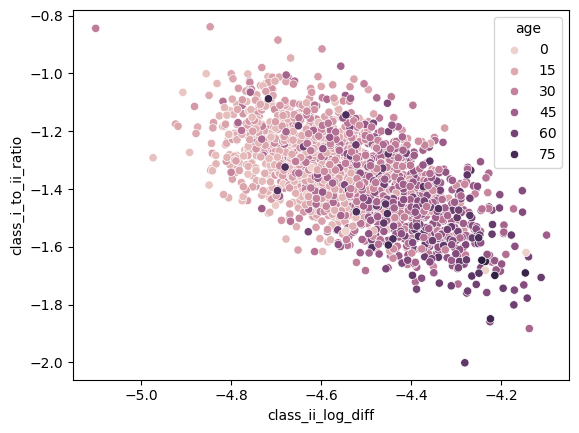

In [109]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)).with_columns(
    ),
    x="class_ii_log_diff",
    y="class_i_to_ii_ratio",
    hue="age",
)

In [111]:
stat_annot

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,n_v_trim_mean,n_v_trim_std,n_v_trim_skew,n_v_trim_kurtosis,n_v_trim_q10,n_v_trim_q25,n_v_trim_q50,n_v_trim_q75,n_v_trim_q90,n_v_trim_sum,n_vd_trim_mean,n_vd_trim_std,n_vd_trim_skew,n_vd_trim_kurtosis,n_vd_trim_q10,n_vd_trim_q25,n_vd_trim_q50,n_vd_trim_q75,n_vd_trim_q90,n_vd_trim_sum,n_vj_trim_mean,n_vj_trim_std,n_vj_trim_skew,n_vj_trim_kurtosis,n_vj_trim_q10,n_vj_trim_q25,n_vj_trim_q50,n_vj_trim_q75,n_vj_trim_q90,n_vj_trim_sum,n_j_trim_mean,n_j_trim_std,n_j_trim_skew,n_j_trim_kurtosis,n_j_trim_q10,n_j_trim_q25,n_j_trim_q50,n_j_trim_q75,n_j_trim_q90,n_j_trim_sum,n_vd_ins_mean,n_vd_ins_std,n_vd_ins_skew,n_vd_ins_kurtosis,n_vd_ins_q10,n_vd_ins_q25,n_vd_ins_q50,n_vd_ins_q75,n_vd_ins_q90,n_vd_ins_sum,n_dj_ins_mean,n_dj_ins_std,n_dj_ins_skew,n_dj_ins_kurtosis,n_dj_ins_q10,n_dj_ins_q25,n_dj_ins_q50,n_dj_ins_q75,n_dj_ins_q90,n_dj_ins_sum,n_trims_mean,n_trims_std,n_trims_skew,n_trims_kurtosis,n_trims_q10,n_trims_q25,n_trims_q50,n_trims_q75,n_trims_q90,n_trims_sum,n_ins_mean,n_ins_std,n_ins_skew,n_ins_kurtosis,n_ins_q10,n_ins_q25,n_ins_q50,n_ins_q75,n_ins_q90,n_ins_sum,cdr3_end_mean,cdr3_end_std,cdr3_end_skew,cdr3_end_kurtosis,cdr3_end_q10,cdr3_end_q25,cdr3_end_q50,cdr3_end_q75,cdr3_end_q90,cdr3_end_sum,frac_untemplated_mean,frac_untemplated_std,frac_untemplated_skew,frac_untemplated_kurtosis,frac_untemplated_q10,frac_untemplated_q25,frac_untemplated_q50,frac_untemplated_q75,frac_untemplated_q90,frac_untemplated_sum,observed,d50,shannon_wiener_index,chao1,gini,shannon_wiener,normalized_shannon_wiener,inverse_simpson,gini_simpson,efron_thisted,total_cmv_duplicates,median_duplicates,mean_duplicates,n_hits,n_unique_ecoclusters,n_unique_hla_coclusters,breadth,A,B,C,DP,DQ,DR,class_i_to_ii_ratio,class_i,class_ii,A_wt,B_wt,C_wt,DP_wt,DQ_wt,DR_wt,class_i_to_ii_ratio_wt,class_i_wt,class_ii_wt,A_wt_with_max,B_wt_with_max,C_wt_with_max,DP_wt_with_max,DQ_wt_with_max,DR_wt_with_max,class_i_to_ii_ratio_wt_with_max,class_i_wt_with_max,class_ii_wt_with_max,TRBV2,TRBV3-1,TRBV4-1,TRBV4-2,TRBV4-3,TRBV5-1,TRBV5-4,TRBV5-5,TRBV5-6,TRBV5-8,TRBV6-1,TRBV6-3,TRBV6-4,TRBV6-5,TRBV6-6,TRBV6-8,TRBV6-9,TRBV7-2,TRBV7-3,TRBV7-4,TRBV7-6,TRBV7-7,TRBV7-8,TRBV7-9,TRBV9,TRBV10-2,TRBV10-3,TRBV11-1,TRBV11-2,TRBV11-3,TRBV12-3,TRBV12-4,TRBV12-5,TRBV13,TRBV14,TRBV15,TRBV16,TRBV18,TRBV19,TRBV20-1,TRBV24-1,TRBV25-1,TRBV27,TRBV28,TRBV29-1,TRBV30,TRBJ1-1,TRBJ1-2,TRBJ1-3,TRBJ1-4,TRBJ1-5,TRBJ1-6,TRBJ2-1,TRBJ2-2,TRBJ2-3,TRBJ2-4,TRBJ2-5,TRBJ2-6,TRBJ2-7,bias_TRBV2+TRBJ1-1,bias_TRBV2+TRBJ1-2,bias_TRBV2+TRBJ1-3,bias_TRBV2+TRBJ1-4,bias_TRBV2+TRBJ1-5,bias_TRBV2+TRBJ1-6,bias_TRBV2+TRBJ2-1,bias_TRBV2+TRBJ2-2,bias_TRBV2+TRBJ2-3,bias_TRBV2+TRBJ2-4,bias_TRBV2+TRBJ2-5,bias_TRBV2+TRBJ2-6,bias_TRBV2+TRBJ2-7,bias_TRBV3-1+TRBJ1-1,bias_TRBV3-1+TRBJ1-2,bias_TRBV3-1+TRBJ1-3,bias_TRBV3-1+TRBJ1-4,bias_TRBV3-1+TRBJ1-5,bias_TRBV3-1+TRBJ1-6,bias_TRBV3-1+TRBJ2-1,bias_TRBV3-1+TRBJ2-2,bias_TRBV3-1+TRBJ2-3,bias_TRBV3-1+TRBJ2-4,bias_TRBV3-1+TRBJ2-5,bias_TRBV3-1+TRBJ2-6,bias_TRBV3-1+TRBJ2-7,bias_TRBV4-1+TRBJ1-1,bias_TRBV4-1+TRBJ1-2,bias_TRBV4-1+TRBJ1-3,bias_TRBV4-1+TRBJ1-4,bias_TRBV4-1+TRBJ1-5,bias_TRBV4-1+TRBJ1-6,bias_TRBV4-1+TRBJ2-1,bias_TRBV4-1+TRBJ2-2,bias_TRBV4-1+TRBJ2-3,bias_TRBV4-1+TRBJ2-4,bias_TRBV4-1+TRBJ2-5,bias_TRBV4-1+TRBJ2-6,bias_TRBV4-1+TRBJ2-7,bias_TRBV4-2+TRBJ1-1,bias_TRBV4-2+TRBJ1-2,bias_TRBV4-2+TRBJ1-3,bias_TRBV4-2+TRBJ1-4,bias_TRBV4-2+TRBJ1-5,bias_TRBV4-2+TRBJ1-6,bias_TRBV4-2+TRBJ2-1,bias_TRBV4-2+TRBJ2-2,bias_TRBV4-2+TRBJ2-3,bias_TRBV4-2+TRBJ2-4,bias_TRBV4-2+TRBJ2-5,bias_TRBV4-2+TRBJ2-6,bias_TRBV4-2+TRBJ2-7,bias_TRBV4-3+TRBJ1-1,bias_TRBV4-3+TRBJ1-2,bias_TRBV4-3+TRBJ1-3,bias_TRBV4-3+TRBJ1-4,bias_TRBV4-3+TRBJ1-5,bias_TRBV4-3+TRBJ1-6,bias_TRBV4-3+TRBJ2-1,bias_TRBV4-3+TRBJ2-2,bias_TRBV4-3+TRBJ2-3,bias_TRBV4-3+TRBJ2-4,bias_TRBV4-3+TRBJ2-5,bias_TRBV4-3+TRBJ2-6,bias_TRBV4-3+TRBJ2-7,bias_TRBV5-1+TRBJ1-1,bias_TRBV5-1+TRBJ1-2,bias_TRBV5-1+TRBJ1-3,bias_TRBV5-1+TRBJ1-4,bias_TRBV5-1+TRBJ1-5,bias_TRBV5-1+TRBJ1-6,bias_TRBV

<Axes: xlabel='n_mait_hits', ylabel='class_ii_log_diff'>

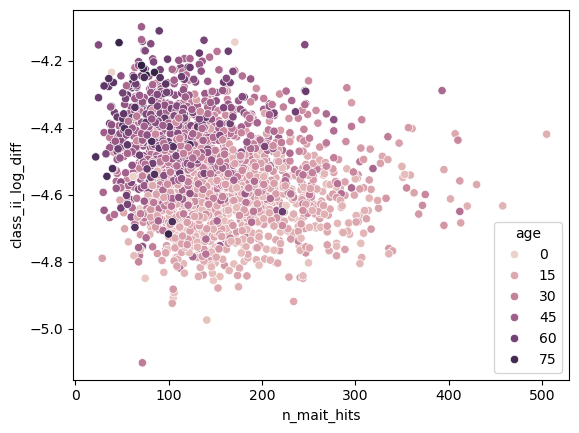

In [112]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)).with_columns(
    ).with_columns(
        norm_mait_hits = pl.col("n_mait_hits") / pl.col("n_clonotypes")
    ),
    x="n_mait_hits",
    y="class_ii_log_diff",
    hue="age",
)

In [113]:
X.shape

(2072, 805)

In [114]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import warnings
from scipy.stats import pearsonr

warnings.simplefilter("ignore", category=UserWarning)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)
feature_importances = np.zeros(len(feature_names))

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_lambda': 1.0,
    'verbosity': -1,
    'seed': 42,
}
# params = {'objective': 'regression',
# 'metric': 'rmse',
# 'n_jobs': -1,
# 'verbose': -1,
# 'learning_rate': 0.012656798450590041,
# 'num_leaves': 244,
# 'max_depth': 11,
# 'min_child_samples': 58,
# 'subsample': 0.5332544377614671,
# 'subsample_freq': 7,
# 'colsample_bytree': 0.9097354337827465,
# 'reg_alpha': 0.23687613557109877,
# 'reg_lambda': 2.8054226336348345,
# 'min_split_gain': 0.34670893130689845}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]


    model = lgb.LGBMRegressor(n_estimators=1000, **params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    oof_predictions[val_idx] = model.predict(X_val)
    feature_importances += model.feature_importances_ / kf.n_splits

mae = mean_absolute_error(y, oof_predictions)
rmse = root_mean_squared_error(y, oof_predictions)
pearson_corr = pearsonr(y, oof_predictions)[0]
print(
    f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Pearson Correlation: {pearson_corr:.4f}"

)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[282]	valid_0's rmse: 8.80926
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[517]	valid_0's rmse: 8.54659
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[603]	valid_0's rmse: 9.08303
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[198]	valid_0's rmse: 9.71158
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[611]	valid_0's rmse: 8.38842
MAE: 6.6537, RMSE: 8.9197, Pearson Correlation: 0.8389


In [115]:
import shap
explainer = shap.TreeExplainer(model, feature_names=feature_names)
shap_values = explainer(X)

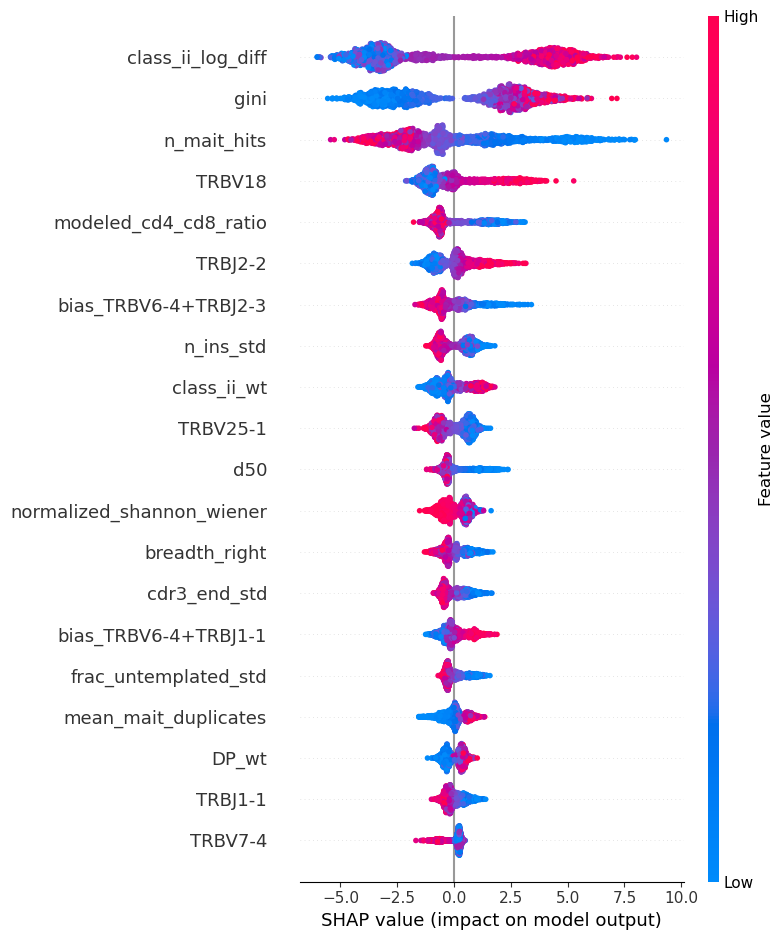

In [116]:
shap.summary_plot(shap_values, X)

In [117]:
feature_names.index("gini")
feature_names.index("class_ii_log_diff")

797

In [118]:
feature_names[353]

'bias_TRBV6-4+TRBJ1-2'

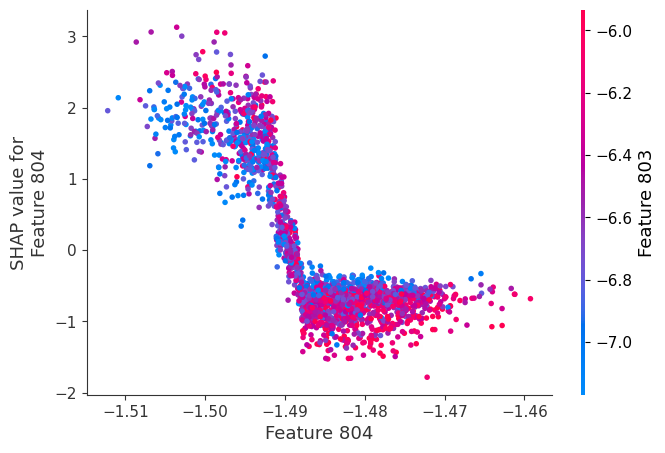

In [121]:
name = feature_names.index("modeled_cd4_cd8_ratio")
shap.dependence_plot(name, shap_values.values, X, display_features=X)

In [122]:
feature_names[803]

'breadth_right'

<Axes: xlabel='modeled_cd4_cd8_ratio', ylabel='breadth_right'>

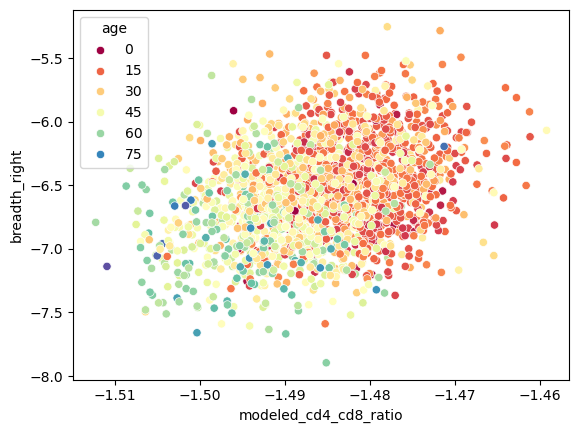

In [123]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)),
    x="modeled_cd4_cd8_ratio",
    y="breadth_right",
    hue="age",
    palette="Spectral"
)

<Axes: xlabel='class_i_log_diff', ylabel='TRBV18'>

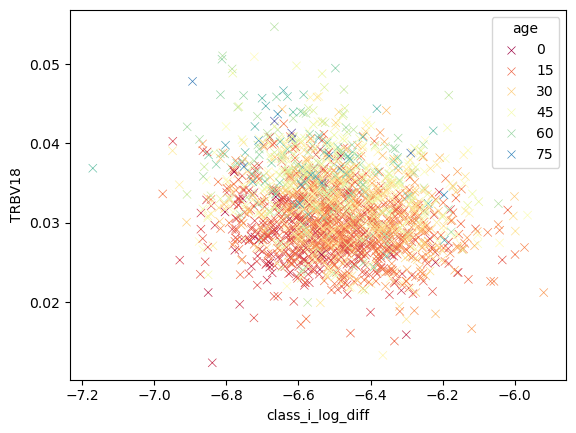

In [124]:
sns.scatterplot(
    data = stat_annot.drop(pl.selectors.by_dtype(pl.List)),
    x="class_i_log_diff",
    y="TRBV18",
    hue="age",
    palette="Spectral",
    marker="x"
)

In [125]:
res_df = stat_annot.with_columns(
    pl.Series(oof_predictions).alias("predicted_age")
)

In [126]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'Predicted vs Actual Age (LGBMRegressor with 5-fold CV), MAE 6.65, pearson=0.839')

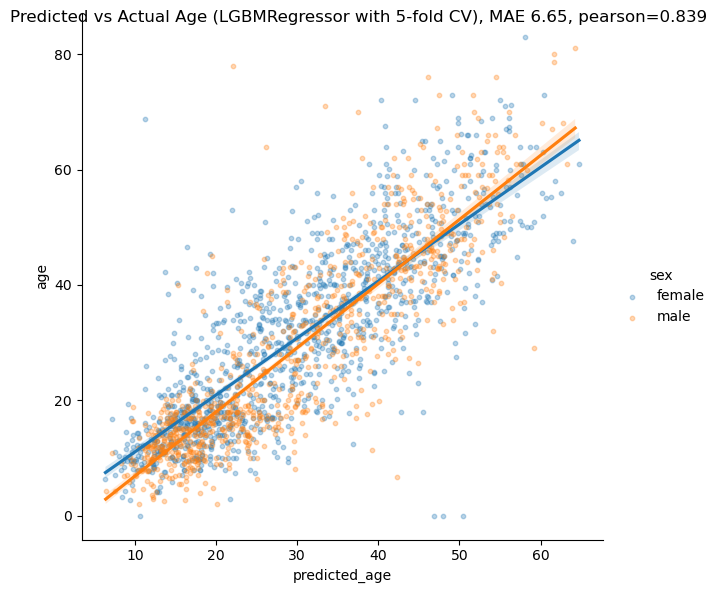

In [127]:
grid = sns.lmplot(
    data = res_df.drop(pl.selectors.by_dtype(pl.List)),
    x="predicted_age",
    y="age",
    hue="sex",
    scatter_kws={"s": 10, "alpha": 0.3, "marker":"x"},
    height=6
)

grid.figure.suptitle(f"Predicted vs Actual Age (LGBMRegressor with 5-fold CV), MAE {mae:.2f}, pearson={pearson_corr:.3f}")

In [16]:
pl.read_ndjson(ds.db_dir / "meta/publication/publication_metadata.ndjson")

identifier,title,abstract,authors,year,source_type,doi,pmid,journal,investigator,sra_accession,error,original_id
str,str,str,list[str],i64,str,str,null,str,null,null,null,str
"""https://clients.adaptivebiotec…","""Immunophenotypic correlates of…","""Open-access immunosequencing d…",[],null,"""adaptive""",null,null,null,null,null,null,"""https://clients.adaptivebiotec…"
"""10.1038/s41467-023-40966-8""","""Immunophenotypic correlates of…","""AbstractThe role of the immune…","[""David G. Coffey"", ""Francesco Maura"", … ""Ola Landgren""]",2023,"""doi""","""10.1038/s41467-023-40966-8""",null,"""Nature Communications""",null,null,null,"""https://clients.adaptivebiotec…"
"""10.21417/DGC2023NC""","""Immunophenotypic correlates of…",null,"[""DG Coffey"", ""F Maura"", … ""O Landgren""]",null,"""doi""","""10.21417/DGC2023NC""",null,"""immuneACCESS""",null,null,null,"""https://clients.adaptivebiotec…"
"""10.1371/journal.pone.0334053""","""Machine learning reveals disti…","""T-cell receptor (TCR) repertoi…","[""David G. Coffey"", ""Yong Zhang"", … ""Dickran Kazandjian""]",2025,"""doi""","""10.1371/journal.pone.0334053""",null,"""PLOS One""",null,null,null,"""https://doi.org/10.1371/journa…"


In [18]:
publication_ids = ds.publication_meta["publication_id"]
    

In [23]:
publication_ids = ['https://clients.adaptivebiotech.com/pub/coffey-2023-nc',
 'https://doi.org/10.1371/journal.pone.0334053', "nonsense"]

In [30]:
from collections import OrderedDict

In [37]:
result_ndjson = []

for pub_id in publication_ids:
    pub_cl = classify_id(pub_id)
    if pub_cl.source_type != "unknown":
        pub_meta = fetch_metadata(pub_cl)
        for r in pub_meta:
            r = asdict(r)
            r["original_id"] = pub_id
            result_ndjson.append(r)

In [38]:
pub_meta

[StudyMetadata(identifier='10.1371/journal.pone.0334053', title='Machine learning reveals distinct T-cell receptor clusters in plasma cell dyscrasias compared to healthy controls', abstract='T-cell receptor (TCR) repertoire diversity has been implicated in the progression and prognosis of multiple myeloma (MM). This study aimed to evaluate the association between T-cell clonality, immune response, and clinical outcomes in patients with plasma cell dyscrasias using next-generation sequencing of the TCR β chain (TCRB). TCRB sequencing was performed on peripheral blood samples from patients with monoclonal gammopathy of undetermined significance (MGUS), smoldering multiple myeloma (SMM), and newly diagnosed multiple myeloma (MM). Healthy individuals served as controls. No significant differences in TCR repertoire diversity were observed between healthy individuals and those with MGUS, SMM or MM after adjusting for age. Furthermore, TCR diversity did not correlate with treatment response i

In [39]:
result_ndjson

[{'identifier': 'https://clients.adaptivebiotech.com/pub/coffey-2023-nc',
  'title': 'Immunophenotypic correlates of sustained MRD negativity in patients with multiple myeloma',
  'abstract': 'Open-access immunosequencing data | Coffey, David G. | Nature Communications | Adaptive Biotechnologies | The role of the immune microenvironment in maintaining disease remission in patients with multiple myeloma (MM) is not well understood. We comprehensively profiled the immune system in patients with newly diagnosed MM receiving continuous lenalidomide maintenance therapy with the aim of uncovering correlates of long-term treatment response. Leveraging single-cell RNA sequencing and T cell receptor β sequencing of the peripheral blood and CyTOF mass cytometry of the bone marrow, we longitudinally characterized the immune landscape in 23 patients before and one year after lenalidomide exposure. We compared patients achieving sustained minimal residual disease (MRD) negativity to patients who ne

In [25]:
pub_cl

ClassifiedIdentifier(raw='nonsense', extracted_id='nonsense', source_type='unknown')

In [6]:
# ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490"))
# ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman_subset"))
ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman"))


In [7]:
ds

TcrDataset 'adaptive_gittelman', created_on 2026-05-28, 861740476 clonotypes (2886 repertoires, 2886 patients).

In [8]:
ds.full_publication_meta

publication_id
str
"""10.1172/jci.insight.151849"""


In [18]:
from tcr_io.operations.filtering_report import FilteringReport

In [19]:
ds.run_operation(
    FilteringReport()
)

/data/current/projects/tcrio/tcrio/tcr_io/dataset.py:89: UserWarning: Operation filtering_report v0.2 has already been run successfully on this dataset. Skipping.
  warnings.warn(f"Operation {operation.name} v{operation.version} has already been run successfully on this dataset. Skipping.")


In [25]:
ds.get_operation_result("filtering_report", "junction_aa")

junction_aa,count
str,u32
"""CASS*ETQYF""",1525
"""F""",1299
"""CASSL*ETQYF""",1160
"""QYF""",1120
"""YEQYF""",1092
…,…
"""CARSLVMQR*PQHF""",1
"""CSA*RD*RGDSYEQYF""",1
"""CASSKEGFD*RYEQYF""",1


In [26]:
ds.get_operation_result("filtering_report", "non_functional_j")

j_call,count
str,u32
"""TRBJ2-7*02""",2549932
"""TRBJ2-2P*01""",203


In [31]:
from tcr_io.operations.hla import HlaInference

In [32]:
ds.run_operation(
    HlaInference()
)

/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Iterating repertoires by patient: 100%|██████████| 2886/2886 [01:56<00:00, 24.67it/s]


Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman/meta/patient/inferred_hla.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman/meta/patient/inferred_hla_long.parquet


In [19]:
ds.get_operation_result("hla_inference").select(
    pl.col(pl.Float64).gt(0.90)
).sum().unpivot().sort("value", descending=True)

variable,value
str,u32
"""DP-01:03+04:01""",1550
"""A-02:01""",1074
"""DP-01:03+04:02""",687
"""DR-11:01""",676
"""DP-01:03+02:01""",665
…,…
"""DR-08:06""",0
"""DR-11:06""",0
"""DR-12:02""",0


In [20]:
from tcr_io.operations.tabulate import TabulateByVJ

In [23]:
TabulateByVJ.version = "0.2.1"

In [24]:
ds.run_operation(
    TabulateByVJ()
)

In [20]:
ds

TcrDataset 'adaptive_gittelman', created_on 2026-05-28, 861740476 clonotypes (2886 repertoires, 2886 patients).

In [43]:
TOP_N = 250
junction_col = "junction"
head_dir = ds.db_dir / "temp/heads"
head_dir.mkdir(exist_ok=True, parents=True)

for repertoire_id, df in ds.iter_repertoires(progress_bar=True, progress_desc="Collecting heads"):
    repertoire_id_safe = repertoire_id.replace("/", "_")
    head = df.head(TOP_N).with_columns(
        v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}"),
        j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}"),
    ).sink_parquet(head_dir / f"{repertoire_id_safe}.parquet")

In [44]:
heads_tab_dir = ds.db_dir / "temp/heads_tab"
heads_tab_dir.mkdir(exist_ok=True, parents=True)

pl.scan_parquet(head_dir).select(["v_gene", "j_gene", junction_col, "repertoire_id"]).sink_parquet(
    pl.PartitionBy(heads_tab_dir, key=["v_gene", "j_gene"])
)

In [45]:
from tqdm import tqdm

In [46]:
total_dirs = sum(1 for _ in heads_tab_dir.glob("*/*"))

In [58]:
progress_bar = tqdm(total=total_dirs, desc="Finding shared clones")
shared_clns_list = []
for v in heads_tab_dir.iterdir():
    for j in v.iterdir():
        shared_clns = pl.scan_parquet(j).group_by(["v_gene", "j_gene", junction_col]).agg(
            pl.len().alias("count")
        ).filter(pl.col("count") > 1).collect(engine="streaming")
        shared_clns_list.append(shared_clns)
        progress_bar.update(1)

Finding shared clones: 100%|██████████| 585/585 [03:22<00:00,  2.89it/s] 


In [59]:
shared_clns_list = pl.concat(shared_clns_list).sort("count", descending=True).with_row_index("clone_id")

In [99]:
overlap = pl.scan_parquet(
    head_dir
).join(
    shared_clns_list.lazy(),
    on= ["v_gene", "j_gene", junction_col],
    how="inner"
)

overlap = overlap.join(
    overlap, on="clone_id", how="inner"
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len().alias("n_overlap"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
).collect(engine="streaming")

In [109]:
o = ds.repertoire_meta.select(["repertoire_id", "patient_id", "n_filtered_clonotypes"]).with_columns(join=pl.lit(True))

overlap_overview = o.join(o, on="join", how="full").filter(pl.col("repertoire_id") < pl.col("repertoire_id_right")).drop(["join", "join_right"]).join(
    overlap, on=["repertoire_id", "repertoire_id_right"], how="left"
).with_columns(
    pl.col("n_overlap").fill_null(0),
    pl.col("pearson_corr").fill_null(0),
    pl.col("spearman_corr").fill_null(0),
    pl.col("patient_id").eq(pl.col("patient_id_right")).alias("same_patient")
).sort(
    "n_overlap", descending=True
)

In [113]:
threshold_sus_overlap = 40 # different patient, above this threshold, the overlap is suspicious 
threshold_sus_overlap_absence = 20 # same patient, below this threshold, the absence of overlap is suspicious

In [118]:
overlap_overview = overlap_overview.with_columns(
    flag_sus_overlap = (~pl.col("same_patient")).and_(pl.col("n_overlap")>threshold_sus_overlap),
    flag_sus_overlap_absence = pl.col("same_patient").and_(pl.col("n_overlap")<threshold_sus_overlap_absence)
)

In [ ]:
overlap_overview.select(
    pl.len().alias("total_pairs"),
    pl.col("flag_sus_overlap").sum().alias("sus_overlap"),
    pl.col("flag_sus_overlap_absence").sum().alias("sus_overlap_absence")
).with_columns(
    n_repertoires = ds.repertoire_meta.height
)

total_pairs,sus_overlap,sus_overlap_absence,n_repertoires
u32,u32,u32,i32
4163055,411,0,2886


In [ ]:
import igraph as ig
from scipy.sparse import coo_array 
import networkx as nx

edges = matches_scores.filter(
    # pl.col("timepoint") != pl.col("timepoint_right")
).filter(
    #((pl.col("n_matches")> 10) & (pl.col("pearson_correlation")>0)) | 
    ((pl.col("n_matches")>20) & (pl.col("pearson_correlation")>=0.1))
).select(["repertoire_id", "repertoire_id_right", "n_matches", "node_id", "node_id_right", "pearson_correlation"])

n_nodes = gittel_df.height

node_1, node_2, weights = edges.select(["node_id", "node_id_right", "pearson_correlation"]).to_numpy().T

A = coo_array((weights, (node_1, node_2)), shape=(n_nodes, n_nodes))
A = A + A.T
G = nx.Graph(A)
# connected_comps = list(nx.weakly_connected_components(G.to_directed()))
connected_comps = list(nx.connected_components(G))

In [1]:
import plotly.express as px

px.scatter(
    overlap,
    x="spearman_corr",
    y="n_overlap",
    color="same_patient",
    hover_data=["repertoire_id", "repertoire_id_right"]
)

NameError: name 'overlap' is not defined

In [ ]:
overlap = clns_s.lazy().join(
    clns_s.lazy(),
    on="clone_id"
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len(),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).collect(engine="streaming")



overlap = overlap.join(
    rep_info, on="repertoire_id"
).join(
    rep_info.rename({"repertoire_id": "repertoire_id_right", "clonotype_count": "clonotype_count_right"}), on="repertoire_id_right"
).with_columns(
    (pl.col("len") / pl.min_horizontal(["clonotype_count", "clonotype_count_right"])).alias("overlap_coefficient"),
    pl.col("len").alias("n_clonotypes"),
    (pl.col("patient_id") == pl.col("patient_id_right")).alias("same_patient")
).sort("overlap_coefficient", descending=True)

In [26]:
shared_clns.collect(engine="streaming")

clone_id,v_call,junction,j_call,count
u32,str,str,str,u32
0,"""TRBV6-4*01""","""tgtgccagcagtgacagggacaccggggag…","""TRBJ2-2*01""",323
1,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggagcaca…","""TRBJ2-3*01""",190
2,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggggggcc…","""TRBJ2-1*01""",173
3,"""TRBV6-4*01""","""tgtgccagcagtgggactagcgggagcaca…","""TRBJ2-3*01""",173
4,"""TRBV6-4*01""","""tgtgccagcagtgacagctctggggccaac…","""TRBJ2-6*01""",165
…,…,…,…,…
44920,"""TRBV25-1*01""","""tgtgccagcagtgaacggggggcggagaca…","""TRBJ1-6*02""",2
44921,"""TRBV30*01""","""tgtgcctggagtgtggggacagggggcggg…","""TRBJ1-2*01""",2
44922,"""TRBV6-1*01""","""tgtgccagcagtggggactacaacaatgag…","""TRBJ2-1*01""",2


In [ ]:
h

In [ ]:

top_clns = pl.collect_all([df.head(TOP_N).collect() for _,df in ds.iter_repertoires()])

AttributeError: 'DataFrame' object has no attribute '_ldf'

In [28]:
pl.scan_parquet(ds.db_dir/"tabulated/v_gene=TRBV7-2").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagcagcccgcgacggaacactgaa…","""TRBV7-2*01""","""CASSPRRNTEAFF""","""TRBJ1-1*01""",316,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctggaagaggggtgagaac…","""TRBV7-2*01""","""CASSWKRGENTEAFF""","""TRBJ1-1*01""",91,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttattaagtaggagtaac…","""TRBV7-2*01""","""CASSLLSRSNTEAFF""","""TRBJ1-1*01""",18,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctcccaaccagtgaacact…","""TRBV7-2*01""","""CASSSQPVNTEAFF""","""TRBJ1-1*01""",17,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttagtgggacaaaggaac…","""TRBV7-2*01""","""CASSLVGQRNTEAFF""","""TRBJ1-1*01""",15,true,"""TRBV7-2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""8003623352""","""tgtgccagcagctccacagggcccgagcag…","""TRBV7-2*01""","""CASSSTGPEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagcccgcgagggggcagccgg…","""TRBV7-2*01""","""CASSPRGGSRTYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagccactacaacagggttagc…","""TRBV7-2*01""","""CASSHYNRVSSYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""


In [21]:
tab_dir = ds.db_dir / "tabulated"

In [25]:
ds.repertoire_meta

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates
str,list[str],str,i64,i64,i64
"""03845000012337""","[""03845000012337_TCRB.tsv""]","""03845000012337""",264597,31039,785805
"""03845000012997""","[""03845000012997_TCRB.tsv""]","""03845000012997""",225082,21207,521432
"""03845000013182""","[""03845000013182_TCRB.tsv""]","""03845000013182""",445382,50967,1128402
"""03845000013199""","[""03845000013199_TCRB.tsv""]","""03845000013199""",347390,35438,622741
"""03845000014380""","[""03845000014380_TCRB.tsv""]","""03845000014380""",758127,81583,1225570
…,…,…,…,…,…
"""03855000011910""","[""03855000011910_TCRB.tsv""]","""03855000011910""",734189,70638,1152262
"""03855000011911""","[""03855000011911_TCRB.tsv""]","""03855000011911""",593560,71538,995215
"""03855000011912""","[""03855000011912_TCRB.tsv""]","""03855000011912""",282394,31232,653966


In [37]:

for v in tab_dir.iterdir():
    most_common_clns = []
    for j in v.iterdir():
        v_gene = v.name.split("=")[1]
        j_gene = j.name.split("=")[1]
        df = pl.scan_parquet(j).join(
            ds.repertoire_meta.select(["repertoire_id", "patient_id"]).lazy(), on="repertoire_id", how="left"
        ).group_by(
            ["junction_aa"]
        ).agg(
            pl.col("repertoire_id"),
            pl.col("repertoire_id").n_unique().alias("n_repertoires"),
            pl.col("patient_id").n_unique().alias("n_patients"),
        ).sort(
            "n_repertoires", descending=True
        ).with_columns(
            v_gene = pl.lit(v_gene),
            j_gene = pl.lit(j_gene)
        )
        most_common_clns.append(df)

    most_common_clns = pl.concat(
        most_common_clns
    ).collect(
        engine="streaming"
    )

In [38]:
most_common_clns

junction_aa,repertoire_id,n_repertoires,n_patients,v_gene,j_gene
str,list[str],u32,u32,str,str
"""CASSPQGNQPQHF""","[""03855000011746"", ""03855000011855"", ""03855000011874""]",3,3,"""TRBV12-4""","""TRBJ1-5"""
"""CASSFPGQPQHF""","[""03845000012337"", ""03855000011766""]",2,2,"""TRBV12-4""","""TRBJ1-5"""
"""CASSLPPDQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASRQGSDQPQHF""","[""03855000011700""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASSWTWHQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
…,…,…,…,…,…
"""CASRTTGTNIQYF""","[""03855000011873""]",1,1,"""TRBV12-4""","""TRBJ2-4"""
"""CASSLSGANVLTF""","[""03855000011687""]",1,1,"""TRBV12-4""","""TRBJ2-6"""
"""CASTSSGANVLTF""","[""03855000011703""]",1,1,"""TRBV12-4""","""TRBJ2-6"""


In [33]:
v = "TRBV9"

ds.repertoire_dir

PosixPath('/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman_subset/processed_repertoires')

In [35]:
import polars as pl

In [36]:
vs = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("v_call").unique()).with_columns(v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}")).collect()
js = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("j_call").unique()).with_columns(j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")).collect()

In [38]:
js

j_call,j_gene
str,str
"""TRBJ1-2*01""","""TRBJ1-2"""
"""TRBJ2-5*01""","""TRBJ2-5"""
"""TRBJ1-1*01""","""TRBJ1-1"""
"""TRBJ2-7*01""","""TRBJ2-7"""
"""TRBJ2-6*01""","""TRBJ2-6"""
…,…
"""TRBJ1-6*01""","""TRBJ1-6"""
"""TRBJ2-3*01""","""TRBJ2-3"""
"""TRBJ1-6*02""","""TRBJ1-6"""


In [40]:
# for v_gene, v_alleles in vs.group_by("v_gene").agg(pl.col("v_call")).iter_rows():
#     print(v_gene, v_alleles)

In [42]:
pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").with_columns(
    v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}"),
    j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")
).sink_parquet(
    pl.PartitionBy("temp_tabulated_by_vj_call", key=["v_gene", "j_gene"])
)

In [46]:
pl.scan_parquet("temp_tabulated_by_vj_call/v_gene=TRBV2/").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagagagacgagacagggaggaaca…","""TRBV2*01""","""CARETRQGGTTEAFF""","""TRBJ1-1*01""",717,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtgcgccggcggctgggaac…","""TRBV2*01""","""CASSAPAAGNTEAFF""","""TRBJ1-1*01""",60,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtccggacagggatgctgaa…","""TRBV2*01""","""CASSPDRDAEAFF""","""TRBJ1-1*01""",55,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagttacggaaaggggcagaaa…","""TRBV2*01""","""CASSYGKGQKAFF""","""TRBJ1-1*01""",46,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtaacaaacgccccatgaac…","""TRBV2*01""","""CASSNKRPMNTEAFF""","""TRBJ1-1*01""",44,true,"""TRBV2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""03855000011914""","""tgtgccagcagtgatccggcagcctcatac…","""TRBV2*01""","""CASSDPAASYTNEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcaggggaagaggggcccactac…","""TRBV2*01""","""CASRGRGAHYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcagtgaagcagggtttgacgag…","""TRBV2*01""","""CASSEAGFDEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""


In [28]:
tcrs_with_v = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").filter(pl.col("v_call").is_in(v_alleles)).with_columns(
    v_gene = pl.lit(v_gene)
)

tcrs_with_vj_list = []
for j_gene, j_alleles in js.group_by("j_gene").agg(pl.col("j_call")).iter_rows():
    tcrs_with_vj = tcrs_with_v.filter(pl.col("j_call").is_in(j_alleles)).with_columns(
        j_gene = pl.lit(j_gene)
    )
    tcrs_with_vj_list.append(tcrs_with_vj)

In [29]:
pl.concat(tcrs_with_vj_list).sink_parquet(pl.PartitionBy(f"result/v_gene={v_gene}", key=["j_gene"]))

In [ ]:
tcrs_with_vj = 

In [ ]:
t

In [15]:
ds.run_operation(
    FilteringReport()
)

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.18it/s]


Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_summary.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_junction_aa.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_j_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_j_call.parquet


In [20]:
ds.get_operation_result(
    "filtering_report",
    "v_call"
)

v_call,count
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [21]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [13]:
from time import sleep

In [13]:
op = TestNullOperation()

In [24]:
from tcr_io.filters import Filterer, get_filter_summary

In [25]:
f = Filterer(return_individual_filters=True)

In [26]:
from collections import defaultdict

In [27]:
from tqdm import tqdm

In [50]:
filter_summ.columns

['repertoire_id',
 'not_null_v',
 'not_null_j',
 'not_null_junction',
 'not_null_junction_aa',
 'valid_junction_aa',
 'v_valid_imgt',
 'v_func_imgt',
 'j_valid_imgt',
 'j_func_imgt',
 'consensus']

In [43]:
filter_summ = []
top_invalid = defaultdict(list)


for rep_id, rep in ds.iter_repertoires(progress_bar=True, progress_desc="Creating filtering summary"):
    filtered = f.run(rep).filter(pl.col("filter_pass").eq(False))
    filtered_filters = filtered.select(pl.col("filters")).collect()

    filter_summ.append(
        get_filter_summary(filtered_filters).with_columns(
            repertoire_id = pl.lit(rep_id)
        )
    )

    top_invalid["invalid_junction_aa"].append(
        filtered.filter(
            pl.col("filters").struct.field("valid_junction_aa").eq(False)
        ).group_by("junction_aa").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(True)
            & pl.col("filters").struct.field("v_func_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(True)
            & pl.col("filters").struct.field("j_func_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

filter_summ = pl.concat(filter_summ).pivot(
    on = "filter",
    values = "exclusions",
    index="repertoire_id"   
)

top_invalid_res = dict()
for k,reps in top_invalid.items():
    df = pl.concat(reps)
    top_invalid_res[k] = df.group_by(df.columns[0]).agg(pl.col("len").sum()).sort("len", descending=True).rename({"len":"count"})

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.89it/s]


In [48]:
for reason, df in top_invalid_res.items():
    print(f"Top {reason}:")
    print(df.head(10))


Top invalid_junction_aa:
shape: (10, 2)
┌─────────────────────┬───────┐
│ junction_aa         ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ CASSLMDRGQFVVATP    ┆ 172   │
│ CASS                ┆ 156   │
│ CASSL               ┆ 130   │
│ CASSSHSGGLPLLQ*AVL  ┆ 122   │
│ CASSS               ┆ 116   │
│ CASS*RCGRLFQETQYF   ┆ 101   │
│ CASSY               ┆ 100   │
│ CASSP               ┆ 85    │
│ CASSRPPRDTLGSMGSPSI ┆ 80    │
│ CSD*AEKRERNTEAFF    ┆ 73    │
└─────────────────────┴───────┘
Top invalid_v_call:
shape: (10, 2)
┌─────────────────────────────────┬────────┐
│ v_call                          ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ TRBV12-34*01                    ┆ 151332 │
│ TRBV6-23*01                     ┆ 102203 │
│ TRBV20-1*04_322GA323            ┆ 7689   │
│ TRBV10-3*02_313GCCATCAGTGAGTC3… ┆ 6991   │
│ TRBV14

In [41]:
top_invalid_res["invalid_v_call"].head(20)

v_call,len
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [26]:
ds.repertoire_meta.join(
    filter_summ, on="repertoire_id", how="left"
)

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,not_null_v,not_null_j,not_null_junction,not_null_junction_aa,valid_junction_aa,v_valid_imgt,v_func_imgt,j_valid_imgt,j_func_imgt,consensus
str,list[str],str,i64,i64,i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""healthy10""","[""PRJEB33490_TRB_healthy10_PRJEB33490_TRB.tsv""]","""healthy10""",16630,5977,55381,0,0,0,0,4207,1589,181,0,0,0
"""healthy11""","[""PRJEB33490_TRB_healthy11_PRJEB33490_TRB.tsv""]","""healthy11""",5596,2567,23458,0,0,0,0,1582,915,70,0,0,0
"""healthy12""","[""PRJEB33490_TRB_healthy12_PRJEB33490_TRB.tsv""]","""healthy12""",9476,3328,33339,0,0,0,0,1935,1344,49,0,0,0
"""healthy13""","[""PRJEB33490_TRB_healthy13_PRJEB33490_TRB.tsv""]","""healthy13""",14763,4936,49784,0,0,0,0,2759,2083,94,0,0,0
"""healthy14""","[""PRJEB33490_TRB_healthy14_PRJEB33490_TRB.tsv""]","""healthy14""",7592,2469,34426,0,0,0,0,1437,969,63,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""solid_cancer97""","[""PRJEB33490_TRB_solid_cancer97_PRJEB33490_TRB.tsv""]","""solid_cancer97""",1570,701,7749,0,0,0,0,356,254,33,0,58,0
"""solid_cancer98""","[""PRJEB33490_TRB_solid_cancer98_PRJEB33490_TRB.tsv""]","""solid_cancer98""",1407,417,7893,0,0,0,0,262,150,5,0,0,0
"""solid_cancer99""","[""PRJEB33490_TRB_solid_cancer99_PRJEB33490_TRB.tsv""]","""solid_cancer99""",633,347,3461,0,0,0,0,187,158,2,0,0,0


In [51]:
from collections import defaultdict

In [14]:
ds.get_operation_result("test_null_operation", "filter_pass")

/data/current/projects/tcrio/tcrio/tcr_io/dataset.py:143: UserWarning: Operation test_null_operation (version 0.4.1) failed. Skipping.
  warnings.warn(f"Operation {op.operation_name} (version {op.version}) failed. Skipping.")


repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [15]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [20]:
pl.scan_parquet(ds.repertoire_dir).filter(
    pl.col("filter_pass")
).collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass
str,str,str,str,str,i64,bool
"""healthy1""","""tgtgccaccagcagagtgagcagccaagag…","""TRBV15*02""","""CATSRVSSQETQYF""","""TRBJ2-5*01""",844,true
"""healthy1""","""tgtgccagtagtaccgggacggggatcaca…","""TRBV19*01""","""CASSTGTGITDTQYF""","""TRBJ2-3*01""",436,true
"""healthy1""","""tgtgccagcagcttagcggagggactggga…","""TRBV11-1*01""","""CASSLAEGLGYEQYF""","""TRBJ2-7*01""",371,true
"""healthy1""","""tgtgccaccagcaggactagcgcccaagag…","""TRBV15*02""","""CATSRTSAQETQYF""","""TRBJ2-5*01""",277,true
"""healthy1""","""tgtgccagcagcttgacagatacgcagtat…","""TRBV5-6*01""","""CASSLTDTQYF""","""TRBJ2-3*01""",242,true
…,…,…,…,…,…,…
"""solid_cancer99""","""tgtgccagcagcccccccgggactagcgga…","""TRBV7-6*01""","""CASSPPGTSGRYAVF""","""TRBJ2-3*01""",1,true
"""solid_cancer99""","""tgcagtgatagagatatggctagcgggccc…","""TRBV20-1*01""","""CSDRDMASGPYNEQFF""","""TRBJ2-1*01""",1,true
"""solid_cancer99""","""tgtgccgacagcccggaccgctatggctac…","""TRBV6-5*01""","""CADSPDRYGYTF""","""TRBJ1-2*01""",1,true


In [16]:
ds.get_operation_result("test_null_operation")

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [20]:
from tcr_io.operations.base import OperationMeta

In [21]:
import json

In [22]:
operations = []
with open(ds.db_dir/"meta/operations.json", "r") as f:
    for line in f.readlines():
        json_obj = json.loads(line)
        operations.append(OperationMeta(**json_obj))

In [29]:
operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [30]:
ds.get_operation_result(op.name)

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [70]:
ds.generation_meta

{'dataset_name': 'PRJEB33490',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PREBJ33490/*.tsv',
 'reader': "WeirdBpAirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)'}

In [72]:
import datetime

In [ ]:
di = DatasetIngester(
    db_dir  ="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name = "test_dataset3",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    # reader = ReaderFactory(),
    publication_ids = ["PRJNA123456", "10.1234/example.doi"]
)

In [71]:
di.run( "/data/current/datasets/to_process/PRJNA1152888/*.tsv")

FileExistsError: Dataset already exists: /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490.

In [5]:
from tcr_io.dataset import TcrDataset

In [6]:
ds = TcrDataset(
    db_dir=Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp"),
    db_name="test_dataset3"
)

In [7]:
ds

TcrDataset test_dataset3, created_on 2026-05-18, 1214419 clonotypes (33 repertoires, 5 patients).

In [9]:
import polars as pl

In [14]:
ds.generation_meta

{'dataset_name': 'test_dataset3',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PRJNA1152888/*.tsv',
 'reader': "ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=(Sample\\_\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=(Sample\\_\\d), group=1)'}

In [8]:
ds.generation_meta.collect()

dataset_name,created_on,source,reader,repertoire_mapper,patient_mapper
str,date,str,str,str,str
"""test_dataset3""",2026-05-18,"""/data/current/datasets/to_proc…","""ReaderFactory, last_resolved_r…","""RegexMapper(pattern=(Sample\_\…","""RegexMapper(pattern=(Sample\_\…"


In [8]:
import polars as pl

In [9]:
from tcr_io.schema import GENERATION_META

In [13]:
pl.read_ndjson(di.db_dir/"meta"/"generation.json").cast(GENERATION_META)[0, "reader"]

"ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})"

In [ ]:
import polars as pla

In [2]:
from tcr_io.schema import REPERTOIRE, REPERTOIRE_META, PATIENT_META, GENERATION_META

In [3]:
from tcr_io.readers import MixcrReader, ReaderFactory
from pathlib import Path
import polars as pl

In [ ]:
data_path =

In [5]:
rf = ReaderFactory()

In [6]:
import pandas as pd

In [7]:
from tcr_io.readers import ReaderFactory

In [ ]:
from collections import defaultdict
from tcr_io.mappers import BaseMapper
from tcr_io.readers import BaseReader, ReaderFactory
from typing import List
import logging
from tcr_io.dataset import TcrDataset
from tqdm import tqdm



logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

def _process_path_wildcards(f: Path|str) -> List[Path]:
    path = Path(f)
    if path.is_file():
        return [path]
    elif path.is_dir():
        return list(path.iterdir())
    elif "*" in f:
        return list(path.parent.glob(path.name))
    else:
        raise ValueError(f"Path {f} is not a file, directory, or wildcard pattern.")

class DatasetIngester:

    def __init__(
        self,
        # raw_dir: str | Path,
        db_dir: str | Path,
        db_name: str,
        repertoire_mapper: BaseMapper,
        patient_mapper: BaseMapper,
        reader: BaseReader | ReaderFactory | None = None,
        publication_ids : List[str] | None = None,
        overwrite: bool = False,
        # repertoire_metadata: Optional[pl.DataFrame] = None,
        # overwrite: bool = False,
    ):
        self.db_dir = Path(db_dir) / db_name
        self.reader = reader or ReaderFactory()
        self.repertoire_mapper = repertoire_mapper
        self.patient_mapper = patient_mapper
        self.db_name = db_name
        self.publication_ids = publication_ids or []

    def _create_structure(self):
        if self.db_dir.exists():
            raise FileExistsError(
                f"Dataset already exists: {self.db_dir}."
            )

        for subdir in TcrDataset.REQUIRED_DIRS + [TcrDataset.TABULATED_DIR]:
            (self.db_dir / subdir).mkdir(parents=True, exist_ok=True)

        
    def _create_mapping(self, dir:Path|str):

        dir : List[Path] = _process_path_wildcards(dir)

        data, skipped_files = self._resolve_dir(dir)
        repertoires = defaultdict(list)
        repertoires_to_patients = dict()

        for file, repertoire_id, patient_id in data:
            repertoires[repertoire_id].append(file)
            repertoires_to_patients[repertoire_id] = patient_id

        return repertoires, repertoires_to_patients, skipped_files

    def _resolve_dir(self, files: List[Path]):
        data = []
        skipped_files = []
        for file in files:
            if file.is_dir():
                continue    
            try:
                repertoire_id = self.repertoire_mapper.transform(file)
                patient_id = self.patient_mapper.transform(file)
                data.append((file, repertoire_id, patient_id))

            except KeyError as e:
                skipped_files.append(file)

        return data, skipped_files
    
    def process(self, dir:Path|str):
        logger.info(f"Processing dataset {self.db_name} from {dir}...")
        self._create_structure()
        logger.info("Creating mappings...")
        repertoires, repertoires_to_patients, skipped = self._create_mapping(dir)
        logger.info(f"Mapping created. {len(repertoires)} repertoires mapped from {len(set(repertoires_to_patients.values()))} unique patients, {len(skipped)} files skipped.")
        self._process_repertoires(repertoires)
        self._generate_repertoire_metadata(repertoires, repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "repertoire" / "repertoire.parquet"
        )
        self._generate_patient_metadata(repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "patient" / "patient.parquet"
        )
        self._generate_publication_metadata(self.publication_ids).write_parquet(
            self.db_dir / "meta" / "publication" / "publication_ids.parquet"
        )
        self._generate_generation_metadata(dir).write_parquet(
            self.db_dir / "meta" / "generation.parquet"
        )
        logger.info("Dataset processing complete.")
    
    def _process_repertoires(self, repertoires):

        for repertoire_id, files in tqdm(repertoires.items(), desc="Reading repertoires"):
            df = self.reader.run(files)
            df = df.with_columns(
                pl.lit(repertoire_id).alias("repertoire_id")
            ).select(REPERTOIRE.keys()).cast(REPERTOIRE)

            repertoire_id_safe = repertoire_id.replace("/", "_")

            df.sink_parquet(self.db_dir/"processed_repertoires"/f"{repertoire_id_safe}.parquet")

    def _generate_repertoire_metadata(self, repertoires, repertoires_to_patients) -> pl.DataFrame:

        df = pl.DataFrame({
            "repertoire_id": repertoires.keys(),
            "source_files": [[f.name for f in files] for files in repertoires.values()],
            "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
        })

        rep_sizes = []

        for f in (self.db_dir/"processed_repertoires").glob("*.parquet"):
            s = pl.scan_parquet(f).select(
                pl.first("repertoire_id"),
                pl.len().alias("n_clonotypes"),
                pl.sum('duplicate_count').alias("total_duplicates")
            )

            rep_sizes.append(s)

        rep_sizes = pl.concat(rep_sizes).collect(engine="streaming")

        df = df.join(rep_sizes, on="repertoire_id", how="left").with_columns(
            pl.col("n_clonotypes").fill_null(0),
            pl.col("total_duplicates").fill_null(0)
        )

        df = df.select(REPERTOIRE_META.keys()).cast(REPERTOIRE_META)

        return df

    def _generate_patient_metadata(self, repertoires_to_patients):

        repertoires_by_patient = defaultdict(list)
        for rep_id, patient_id in repertoires_to_patients.items():
            repertoires_by_patient[patient_id].append(rep_id)
        
        df = pl.DataFrame({
            "patient_id": list(repertoires_by_patient.keys()),
            "patient_repertoires": list(repertoires_by_patient.values()),
            "n_repertoires": [len(repertoires) for repertoires in repertoires_by_patient.values()]
        })

        return df.select(PATIENT_META.keys()).cast(PATIENT_META)
    

    def _generate_publication_metadata(self, publication_ids):
        df = pl.DataFrame({
            "publication_id": publication_ids
        })

        return df.select(PUBLICATION_META.keys()).cast(PUBLICATION_META)
    
    def _generate_generation_metadata(self, data_dir: Path):
        df = pl.DataFrame({
            "dataset_name" : self.db_name,
            "created_on" : pl.now(),
            "source": str(data_dir),
            "reader" : self.reader.__repr__(),
            "repertoire_mapper" : self.repertoire_mapper.__repr__(),
            "patient_mapper" : self.patient_mapper.__repr__(),
        })
        return df.select(GENERATION_META.keys()).cast(GENERATION_META)

        

    def _test_mappers(self, dir:Path|str):
        dir : List[Path] = _process_path_wildcards(dir)
        print("Repertoire mapping : ")
        print("-------------------")
        self.repertoire_mapper.test(dir)
        print("\nPatient mapping : ")
        print("-------------------")
        self.patient_mapper.test(dir)

In [16]:
from tcr_io.mappers import RegexMapper, ChainedMapper, DictMapper

In [12]:
di = DatasetIngester(
    db_dir="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name="test_db12",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    overwrite=True
)

In [27]:
di.repertoire_mapper

In [13]:
di.process(
    "/data/current/datasets/to_process/PRJNA1152888/*.tsv"
)

Reading repertoires: 100%|██████████| 33/33 [00:00<00:00, 44.21it/s]


In [24]:
pl.scan_parquet(
    di.db_dir/"meta"/"repertoire"/"repertoire.parquet"
).select(
    pl.sum("n_clonotypes"),
    pl.len().alias("n_repertoires"),
    pl.n_unique("patient_id")
).collect()

n_clonotypes,n_repertoires,patient_id
i64,u32,u32
1214419,33,5


In [ ]:
pl.read_parquet(di.db_dir/"meta"/"repertoire"/"repertoire.parquet")

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [13]:
repertoires, repertoires_to_patients, skipped = di._create_mapping("/data/current/datasets/to_process/PRJNA1152888/*.tsv")

In [20]:
di._generate_repertoire_metadata(repertoires, repertoires_to_patients)

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [130]:
REP_SCHEMA =  pl.Schema({
    "repertoire_id": pl.Utf8,
    "files": pl.List(pl.Utf8),
    "patient_id": pl.Utf8,
})

In [131]:
rep_df = pl.DataFrame({
    "repertoire_id": repertoires.keys(),
    "files": [[f.name for f in files] for files in repertoires.values()],
    "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
}, schema=REP_SCHEMA)

7.96 ms ± 49.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
ReaderFactory().run(data_path/"PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv")

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count
str,str,str,str,str,i64
"""rep1""","""tgtgccagcagttacagacctggtgacaat…","""TRBV12-4*01""","""CASSYRPGDNEQFF""","""TRBJ2-1*01""",319
"""rep1""","""tgtgccagcacctggtcaggctcggctagc…","""TRBV27*01""","""CASTWSGSASGREDF""","""TRBJ2-3*01""",300
"""rep1""","""tgtgccagcagctataacccgggactaggc…","""TRBV3-1*01""","""CASSYNPGLGYEQYF""","""TRBJ2-7*01""",193
"""rep1""","""tgtgccagcagttatctagcgggcgcgcag…","""TRBV12-4*01""","""CASSYLAGAQAGELFF""","""TRBJ2-2*01""",180
"""rep1""","""tgtgccagcagcttaggaccgggagcgact…","""TRBV7-6*01""","""CASSLGPGATNEKLFF""","""TRBJ1-4*01""",164
…,…,…,…,…,…
"""rep1""","""tgcagtgctagagatctgggcagtaaagag…","""TRBV20-1*05""","""CSARDLGSKEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcaccctcccgggactagcggga…","""TRBV18*01""","""CASTLPGLAGGGEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcagtccccagcgacgcacagat…","""TRBV27*01""","""CASSPQRRTDTQYF""","""TRBJ2-3*01""",1


In [ ]:
REPERTOIRE.

Schema([('repertoire_id', String),
        ('file', String),
        ('junction', String),
        ('v_call', String),
        ('junction_aa', String),
        ('j_call', String),
        ('duplicate_count', Int64)])